# Wprowadzenie

Celem ćwiczenia laboratoryjnego jest zapoznanie sie z najpopularniejszymi metodami wykorzystywanymi do rozwiazywania rzeczywistych problemów zespołami klasyfikatorow. W szczególności celem zadania bedzie przetestowanie modeli takich jak Random Forest, AdaBoost, Histogram-based Gradient Boosting, XGBoost, LightGBM, CatBoost

# Imports

In [1]:
from ucimlrepo import fetch_ucirepo 
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.discriminant_analysis import StandardScaler
from xgboost import XGBClassifier
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, f1_score, recall_score
from sklearn.impute import SimpleImputer

In [ ]:
glass_identification = fetch_ucirepo(id=42) 

X = glass_identification.data.features 
y = glass_identification.data.targets 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Wybór i uruchomienie algorytmów na prostym zbiorze

## Baseline z poprzednich list

In [ ]:
classes = [
    "bld_win_float",
    "bld_win_nonfloat",
    "veh_win_float",
    "containers",
    "tableware",
    "headlamps"
]

def plot_cm(cm):
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
                xticklabels=classes, 
                yticklabels=classes)

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

## KNN

C:\Users\mikja\AppData\Roaming\Python\Python312\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


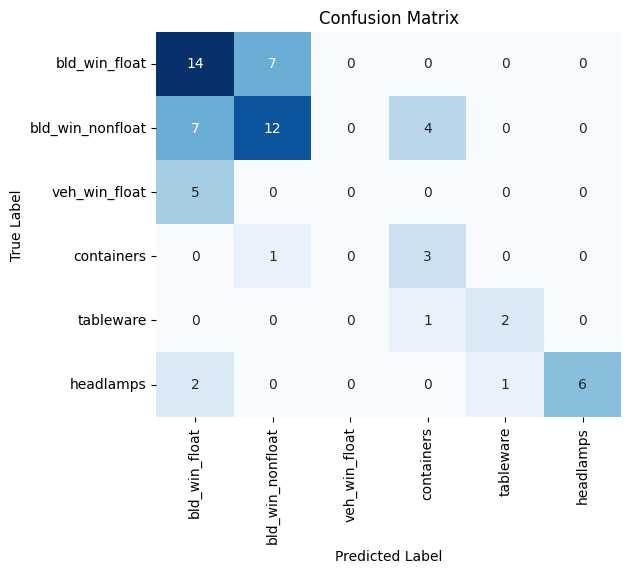

                  precision    recall  f1-score   support

   bld_win_float       0.50      0.67      0.57        21
bld_win_nonfloat       0.60      0.52      0.56        23
   veh_win_float       0.00      0.00      0.00         5
      containers       0.38      0.75      0.50         4
       tableware       0.67      0.67      0.67         3
       headlamps       1.00      0.67      0.80         9

        accuracy                           0.57        65
       macro avg       0.52      0.55      0.52        65
    weighted avg       0.57      0.57      0.55        65



In [ ]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
y_hat = knn.predict(X_test)
plot_cm(confusion_matrix(y_test, y_hat))
print(classification_report(y_test, y_hat, target_names=classes, zero_division=0))

## Decision Tree

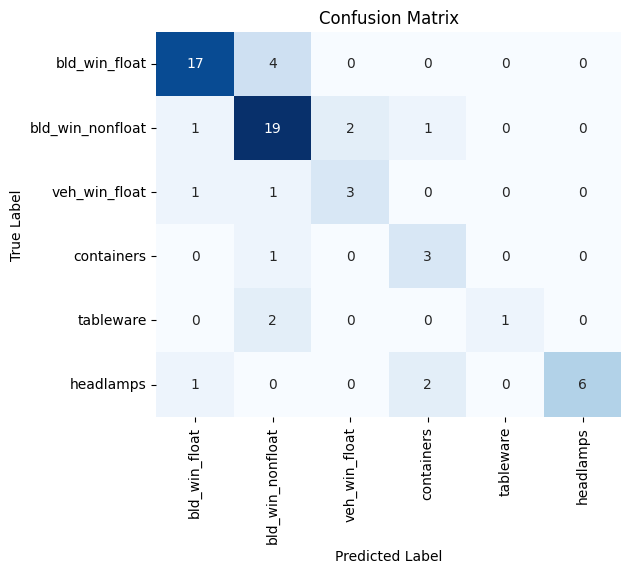

                  precision    recall  f1-score   support

   bld_win_float       0.85      0.81      0.83        21
bld_win_nonfloat       0.70      0.83      0.76        23
   veh_win_float       0.60      0.60      0.60         5
      containers       0.50      0.75      0.60         4
       tableware       1.00      0.33      0.50         3
       headlamps       1.00      0.67      0.80         9

        accuracy                           0.75        65
       macro avg       0.78      0.66      0.68        65
    weighted avg       0.79      0.75      0.75        65



In [ ]:
dt_clf = DecisionTreeClassifier()
dt_clf.fit(X_train, y_train)
y_hat = dt_clf.predict(X_test)
plot_cm(confusion_matrix(y_test, y_hat))
print(classification_report(y_test, y_hat, target_names=classes, zero_division=0))

## Random Fores

C:\Users\mikja\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


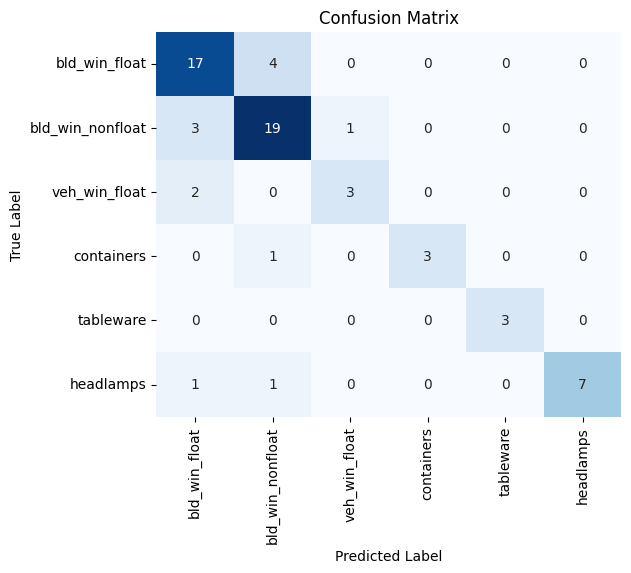

                  precision    recall  f1-score   support

   bld_win_float       0.74      0.81      0.77        21
bld_win_nonfloat       0.76      0.83      0.79        23
   veh_win_float       0.75      0.60      0.67         5
      containers       1.00      0.75      0.86         4
       tableware       1.00      1.00      1.00         3
       headlamps       1.00      0.78      0.88         9

        accuracy                           0.80        65
       macro avg       0.87      0.79      0.83        65
    weighted avg       0.81      0.80      0.80        65



In [ ]:
rf_clf = RandomForestClassifier()
rf_clf.fit(X_train, y_train)
y_hat = rf_clf.predict(X_test)
plot_cm(confusion_matrix(y_test, y_hat))
print(classification_report(y_test, y_hat, target_names=classes, zero_division=0))

## AdaBoost

C:\Users\mikja\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


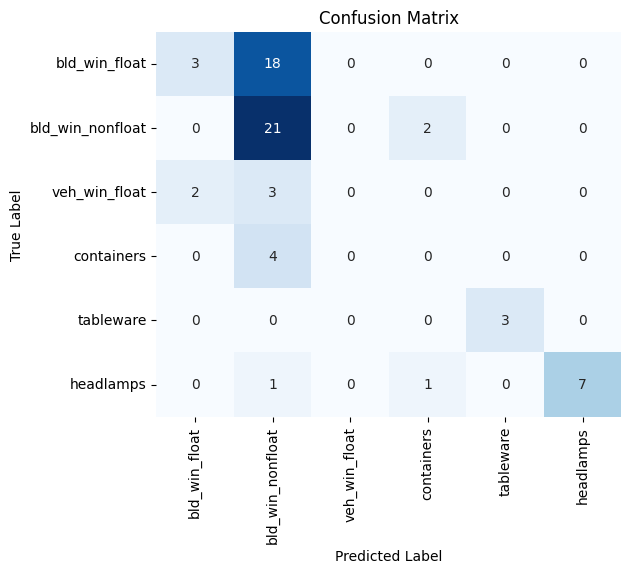

                  precision    recall  f1-score   support

   bld_win_float       0.60      0.14      0.23        21
bld_win_nonfloat       0.45      0.91      0.60        23
   veh_win_float       0.00      0.00      0.00         5
      containers       0.00      0.00      0.00         4
       tableware       1.00      1.00      1.00         3
       headlamps       1.00      0.78      0.88         9

        accuracy                           0.52        65
       macro avg       0.51      0.47      0.45        65
    weighted avg       0.54      0.52      0.45        65



In [ ]:
ada_clf = AdaBoostClassifier()
ada_clf.fit(X_train, y_train)
y_hat = ada_clf.predict(X_test)
plot_cm(confusion_matrix(y_test, y_hat))
print(classification_report(y_test, y_hat, target_names=classes, zero_division=0))

## XGBoost

In [ ]:
y_train = y_train - 1
y_test = y_test - 1
y_train = np.where(y_train > 2, y_train - 1, y_train)
y_test = np.where(y_test > 2, y_test - 1, y_test)

In [ ]:
np.unique(y_test)

array([0, 1, 2, 3, 4, 5])

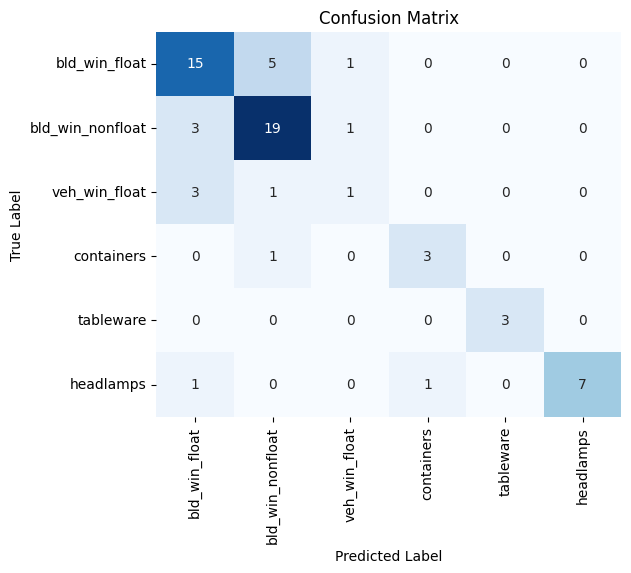

                  precision    recall  f1-score   support

   bld_win_float       0.68      0.71      0.70        21
bld_win_nonfloat       0.73      0.83      0.78        23
   veh_win_float       0.33      0.20      0.25         5
      containers       0.75      0.75      0.75         4
       tableware       1.00      1.00      1.00         3
       headlamps       1.00      0.78      0.88         9

        accuracy                           0.74        65
       macro avg       0.75      0.71      0.72        65
    weighted avg       0.74      0.74      0.73        65



In [ ]:
xgb = XGBClassifier()
xgb.fit(X_train, y_train)
y_hat = xgb.predict(X_test)
plot_cm(confusion_matrix(y_test, y_hat))
print(classification_report(y_test, y_hat, target_names=classes, zero_division=0))

## Podsumowanie

| Klasyfikator  | Accuracy | Macro avg F1 | Weighted avg F1 | Uwagi |
|:---------------|:-----------|:---------------|:----------------|:-----------------------------|
| **KNN**           | 0.57      | 0.52          | 0.55             | Najniższy wynik, lecz najprostszy klasyfikator. Pominięta klasa `veh_win_float` |
| **Decision Tree** | 0.75      | 0.68          | 0.75             | Udało się nie pomijać zawsze ani jednej klasy |
| **Random Forest** | 0.80      | 0.83          | 0.80             | Najlepszy wynik; wysokie F1-score w niemal wszystkich klasach |
| **AdaBoost**      | 0.52      | 0.45          | 0.45             | Bardzo nierównomierny - kompletnie pominął często występującą klasę `bld_win_float`        i uznawał ją za klasę `bld_win_nonfloat` |
| **XGBoost**       | 0.74      | 0.72          | 0.73             | Stabilny, dobre wyniki zbliżone do Decision Tree |



# Zadanie 2 - Detektyw NYPD

## Przewidzieć lub zidentyfikować przypadki, w których CCRB Allegation Disposition ≠ Investigator Recommendatione?
Jest to wykrywanie anomalii / klasyfikacja niezgodności między detektywem a board of NYPD

In [75]:
df = pd.read_csv('civilian_complaint.csv')

df['target_disagreement'] = (df['CCRB Allegation Disposition'] != df['Investigator Recommendation']).astype(int)

X = df.drop(columns=['CCRB Allegation Disposition', 'Investigator Recommendation', 'target_disagreement'])
y = df['target_disagreement']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

## EDA

In [94]:
X_train[X_train['Complaint Id'] == 202000071]

,As Of Date,Complaint Id,Complaint Officer Number,Tax ID,Officer Rank Abbreviation At Incident,Officer Rank At Incident,Officer Command At Incident,Officer Days On Force At Incident,Allegation Record Identity,FADO Type,Allegation,Victim/Alleged Victim Age Range At Incident,Victim/Alleged Victim Gender,Victim / Alleged Victim Race (Legacy),Victim / Alleged Victim Race / Ethnicity,NYPD Allegation Disposition
36434,06/04/2025,202000071,2,962772.0,POF,Police Officer,MTN PCT,1178.0,1083686,Force,Physical force,09 < Age <= 14,Female/Woman,Hispanic,NaN,APU Not guilty
203132,06/04/2025,202000071,1,950110.0,POM,Police Officer,MTN PCT,3102.0,1083098,Force,Physical force,20 < Age <= 24,Male/Man,Hispanic,NaN,APU Not guilty
354171,06/04/2025,202000071,2,962772.0,POF,Police Officer,MTN PCT,1178.0,1108748,Abuse of Authority,Failed to Obtain Language Interpretation,09 < Age <= 14,Female/Woman,Hispanic,NaN,APU Not guilty
272344,06/04/2025,202000071,1,950110.0,POM,Police Officer,MTN PCT,3102.0,1088854,Force,Physical force,NaN,NaN,NaN,NaN,NaN
4965,06/04/2025,202000071,4,966302.0,POM,Police Officer,MTN PCT,549.0,1127303,Force,Physical force,09 < Age <= 14,Female/Woman,Hispanic,NaN,NaN
178850,06/04/2025,202000071,3,942902.0,SGT,Sergeant,MTN PCT,4740.0,1128835,Force,Physical force,20 < Age <= 24,Male/Man,Hispanic,NaN,NaN
359469,06/04/2025,202000071,1,950110.0,POM,Police Officer,MTN PCT,3102.0,1128828,Abuse of Authority,Threat of force (verbal or physical),20 < Age <= 24,Male/Man,Hispanic,NaN,APU Not guilty
214089,06/04/2025,202000071,5,904994.0,SGT,Sergeant,CW T TF,9621.0,1126667,Abuse of Authority,Refusal to provide name,59 < Age <= 64,Male/Man,White,NaN,NaN


z przykrością stwierdzam, że odpowiedni podział danych w tym dataset, odpowiednie przetworzenie danych oraz ogromna dysproporcja w klasach powodują, że zajęłoby to kilka dobrych godzin, aby móc przystąpić do EDA oraz modelowania, a nie na tym polega ta lsita, więc zdecydowałem się zabrać za inny dataset

# Zadanie 2 - Hospital Readmissions

In [230]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

In [231]:
diabetes_130_us_hospitals_for_years_1999_2008 = fetch_ucirepo(id=296) 

diabetes_130 = fetch_ucirepo(id=296)
data = diabetes_130.data.original.copy()

data['readmitted'] = data['readmitted'].apply(lambda x: 1 if x == '<30' else 0)

patient_labels = data.groupby('patient_nbr')['readmitted'].max()
patient_labels = patient_labels.astype(int)

train_patients, test_patients = train_test_split(
    patient_labels.index,
    test_size=0.2,
    stratify=patient_labels.values,
    random_state=42
)

train_df = data[data['patient_nbr'].isin(train_patients)].reset_index(drop=True)
test_df = data[data['patient_nbr'].isin(test_patients)].reset_index(drop=True)

print("Train readmitted rate:", train_df['readmitted'].mean())
print("Test readmitted rate:", test_df['readmitted'].mean())

c:\Users\mikja\AppData\Local\Programs\Python\Python310\lib\site-packages\ucimlrepo\fetch.py:97: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)
c:\Users\mikja\AppData\Local\Programs\Python\Python310\lib\site-packages\ucimlrepo\fetch.py:97: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


Train readmitted rate: 0.11152224421306256
Test readmitted rate: 0.11190557813800872


In [232]:
data

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,0
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,0
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,0
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,0
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),NaN,1,3,7,3,MC,NaN,51,0,16,0,0,0,250.13,291,458,9,NaN,>8,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Down,No,No,No,No,No,Ch,Yes,0
101762,443847782,74694222,AfricanAmerican,Female,[80-90),NaN,1,4,5,5,MC,NaN,33,3,18,0,0,1,560,276,787,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Yes,0
101763,443854148,41088789,Caucasian,Male,[70-80),NaN,1,1,7,1,MC,NaN,53,0,9,1,0,0,38,590,296,13,NaN,NaN,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Down,No,No,No,No,No,Ch,Yes,0
101764,443857166,31693671,Caucasian,Female,[80-90),NaN,2,3,7,10,MC,Surgery-General,45,2,21,0,0,1,996,285,998,9,NaN,NaN,No,No,No,No,No,No,Steady,No,No,Steady,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,0


## EDA

In [233]:
print(train_df.info())
print(train_df.describe(include='all').T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81347 entries, 0 to 81346
Data columns (total 50 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   encounter_id              81347 non-null  int64 
 1   patient_nbr               81347 non-null  int64 
 2   race                      79534 non-null  object
 3   gender                    81347 non-null  object
 4   age                       81347 non-null  object
 5   weight                    2518 non-null   object
 6   admission_type_id         81347 non-null  int64 
 7   discharge_disposition_id  81347 non-null  int64 
 8   admission_source_id       81347 non-null  int64 
 9   time_in_hospital          81347 non-null  int64 
 10  payer_code                49042 non-null  object
 11  medical_specialty         41269 non-null  object
 12  num_lab_procedures        81347 non-null  int64 
 13  num_procedures            81347 non-null  int64 
 14  num_medications       

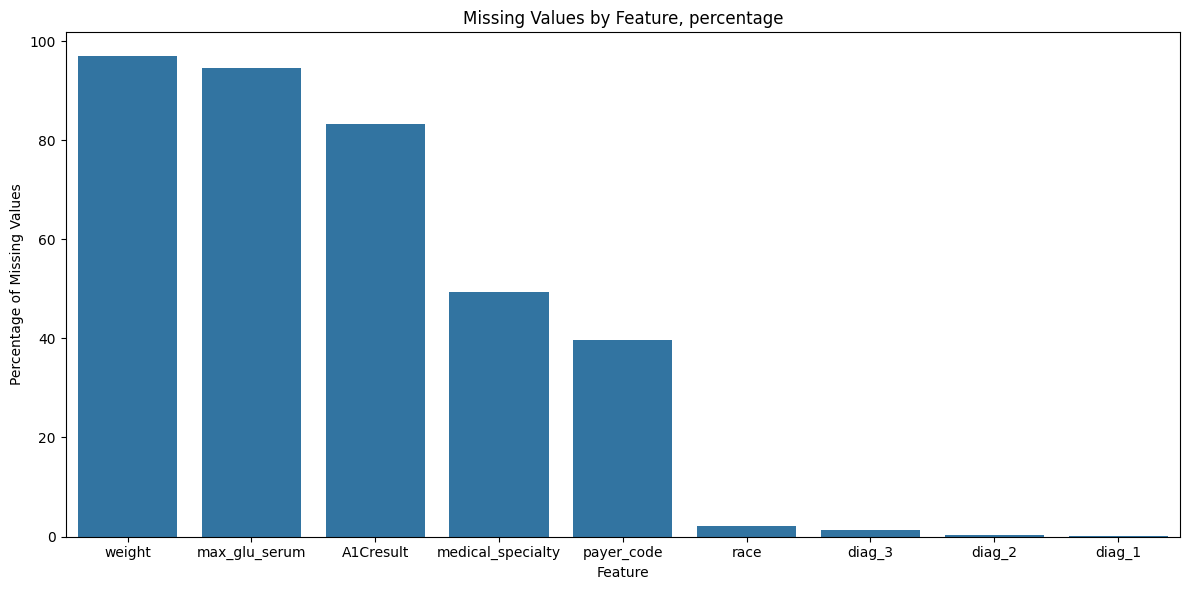

In [234]:
missing_percent = train_df.isnull().mean().sort_values(ascending=False) * 100
missing_percent = missing_percent[missing_percent > 0]

plt.figure(figsize=(12, 6))
sns.barplot(x=missing_percent.index, y= missing_percent.values)
plt.xlabel('Feature')
plt.ylabel('Percentage of Missing Values')
plt.title('Missing Values by Feature, percentage')
plt.tight_layout()
plt.show()


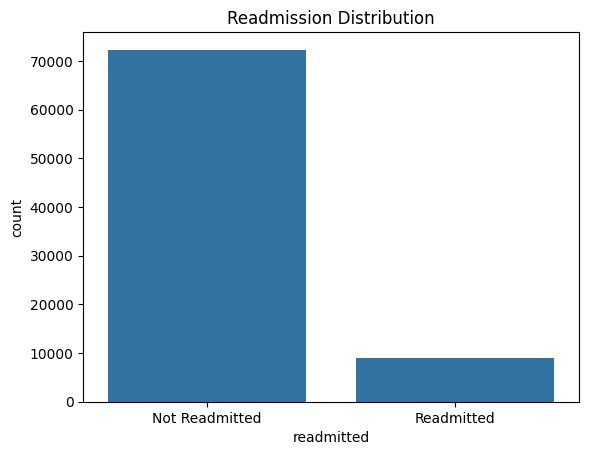

In [235]:
sns.countplot(x='readmitted', data=train_df)
plt.title('Readmission Distribution')
plt.xticks([0, 1], ['Not Readmitted', 'Readmitted'])
plt.show()

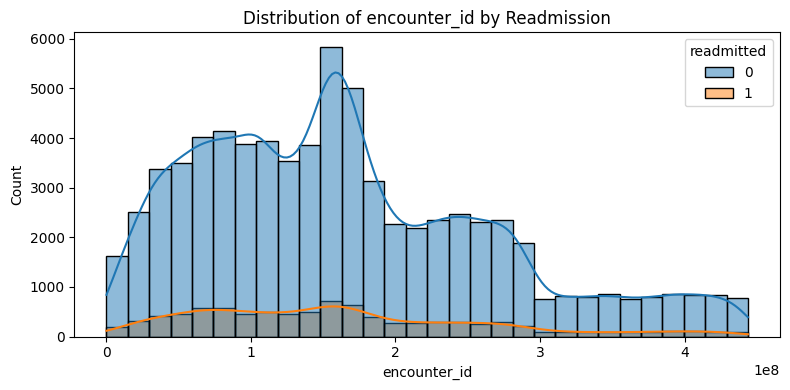

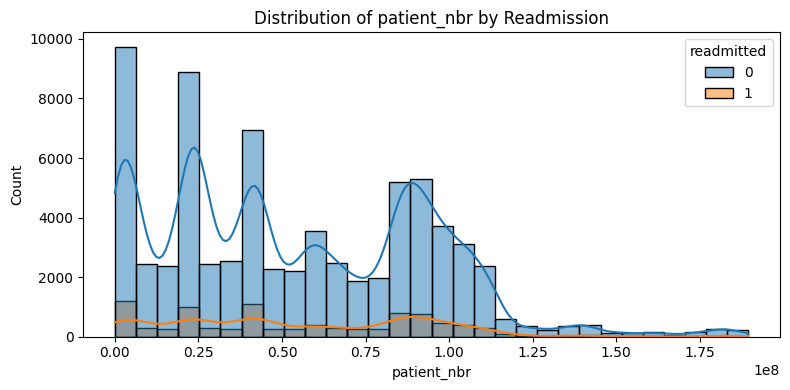

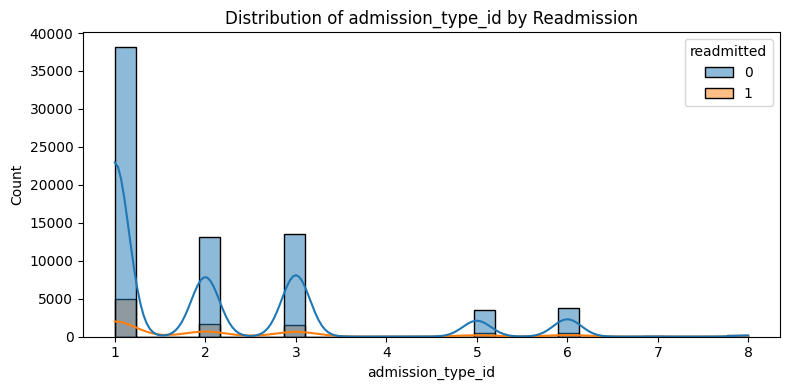

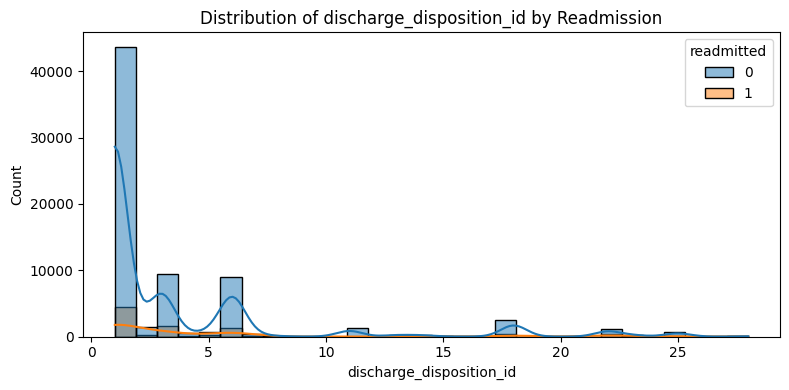

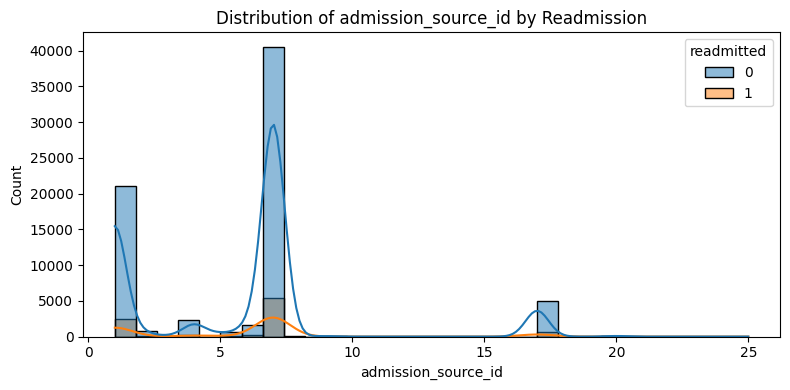

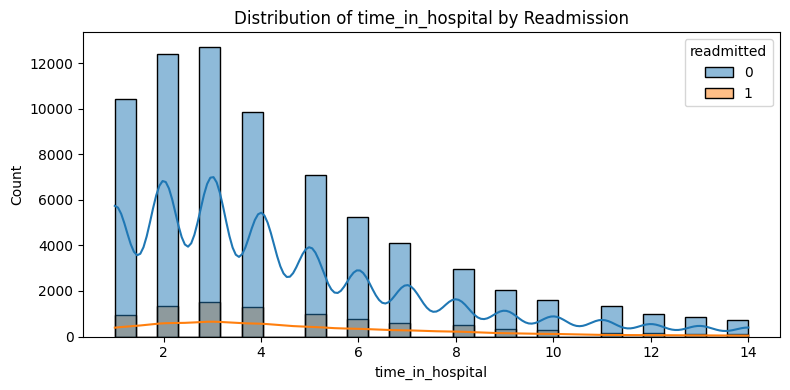

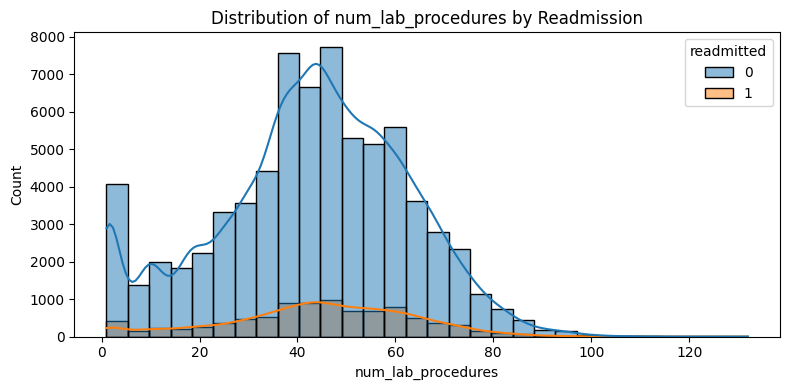

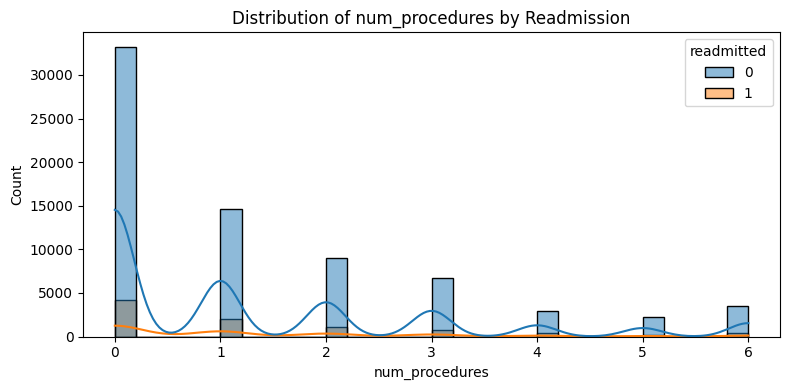

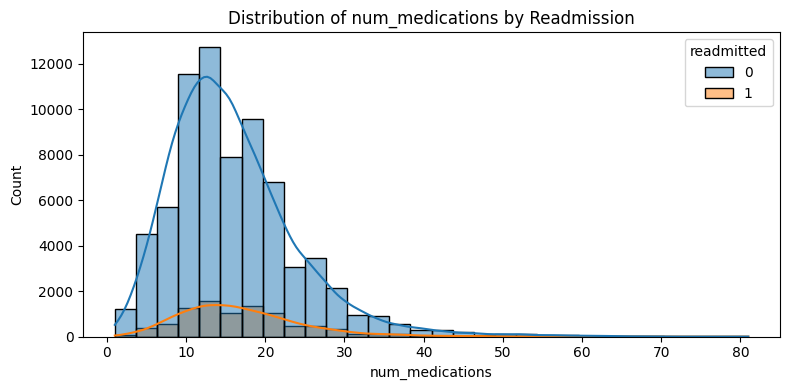

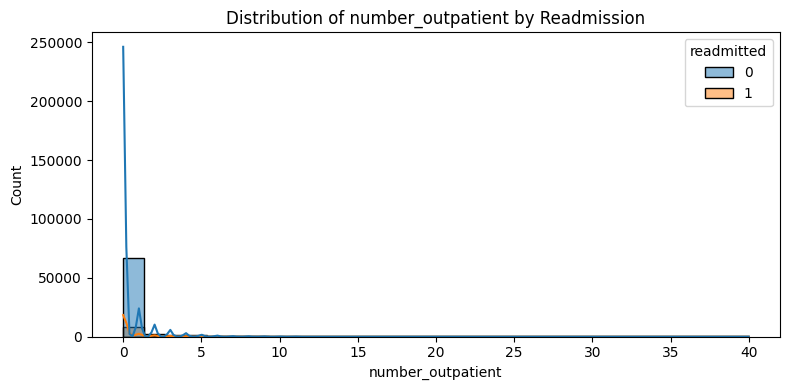

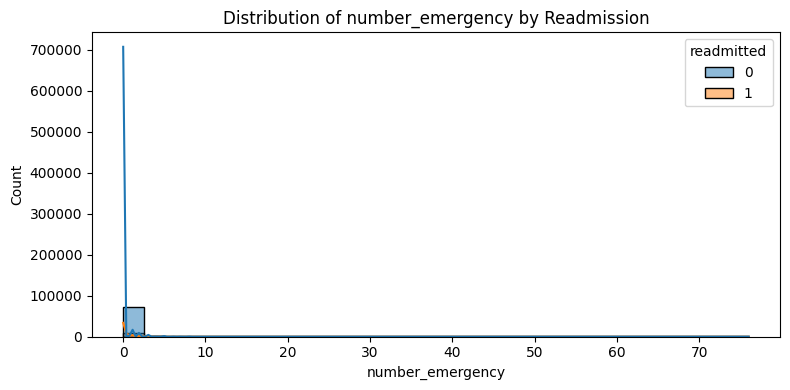

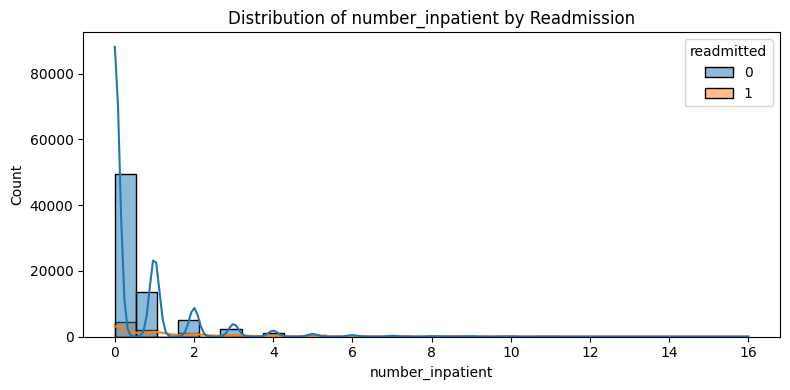

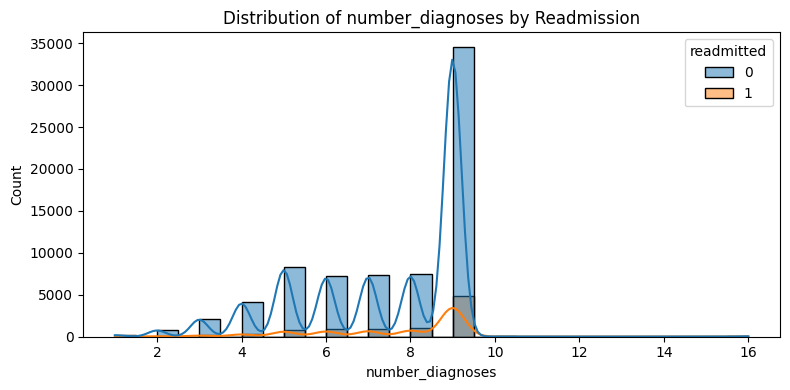

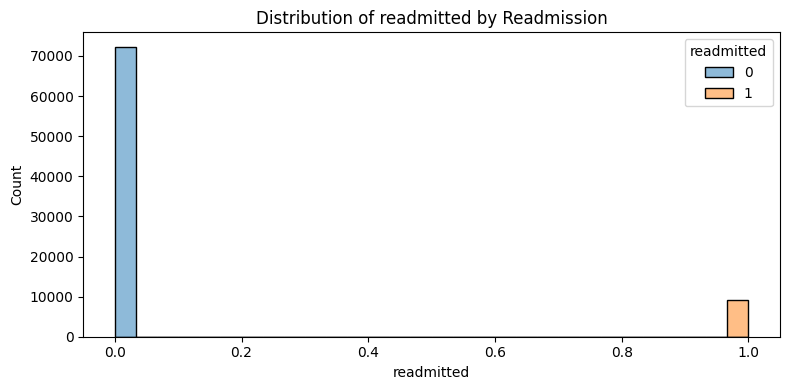

In [236]:
numeric_cols = train_df.select_dtypes(include=np.number).columns.tolist()

for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=train_df, x=col, hue='readmitted', kde=True, bins=30)
    plt.title(f'Distribution of {col} by Readmission')
    plt.tight_layout()
    plt.show()

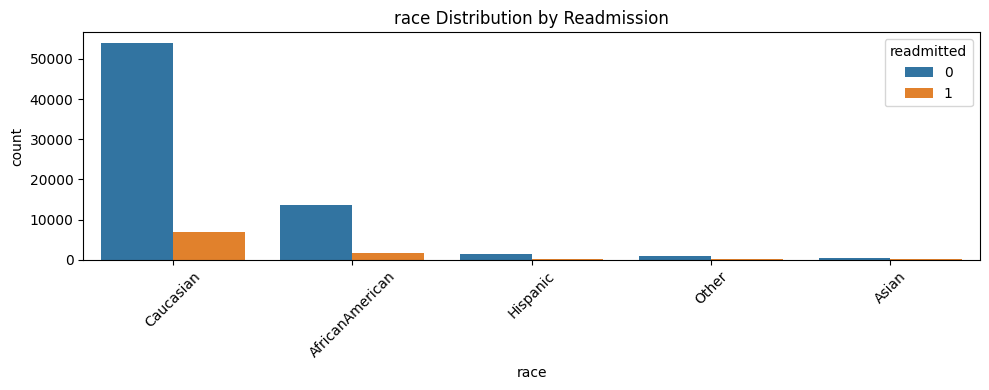

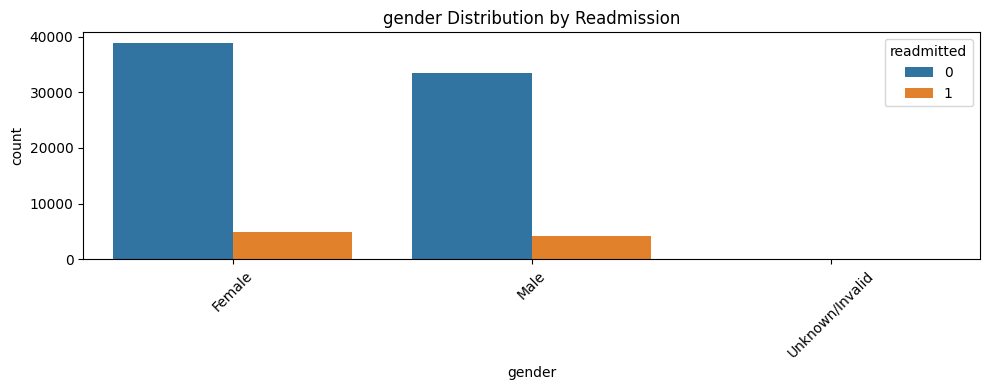

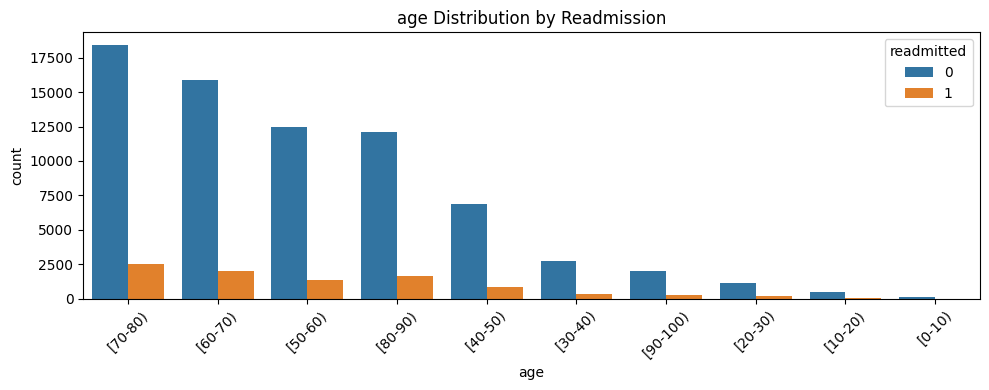

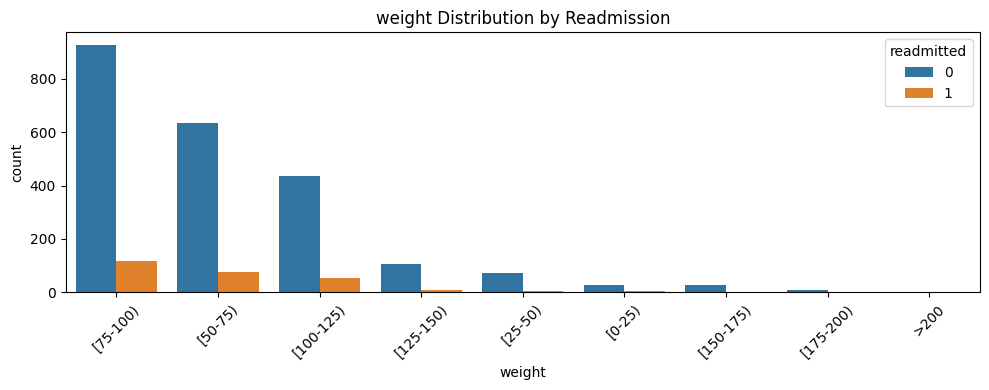

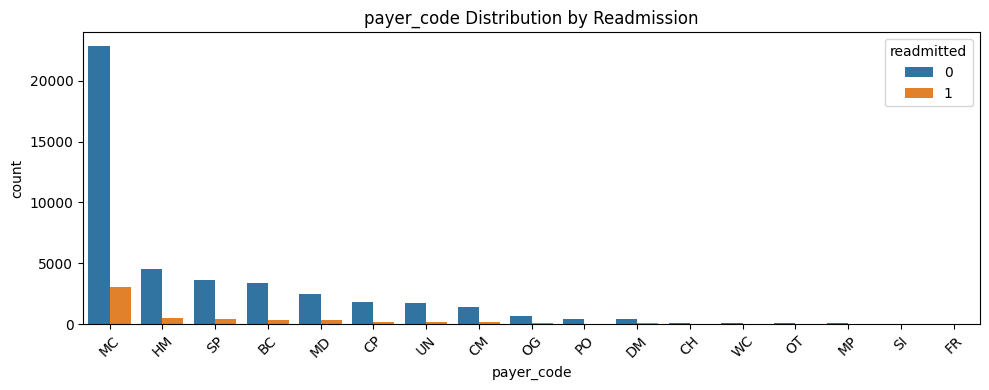

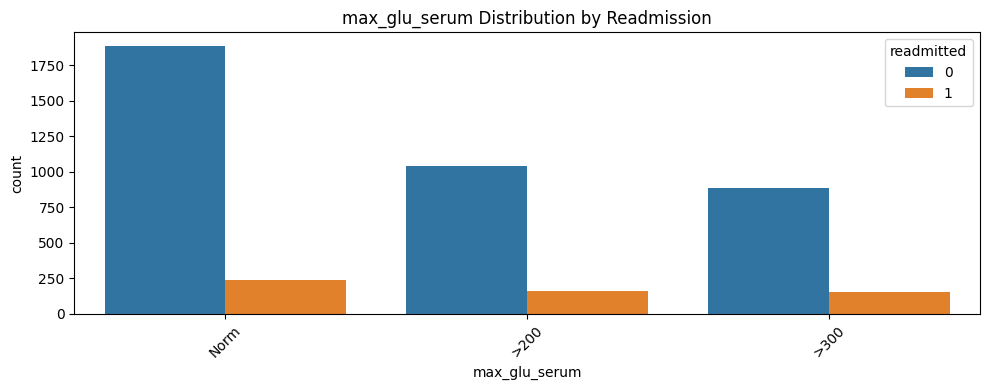

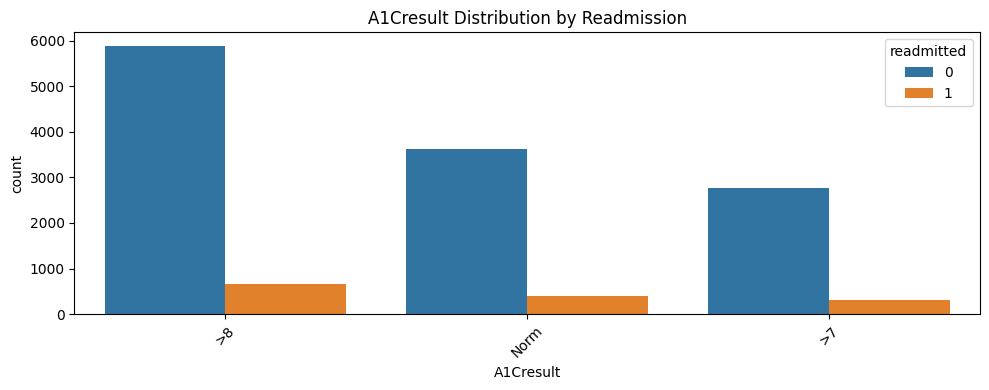

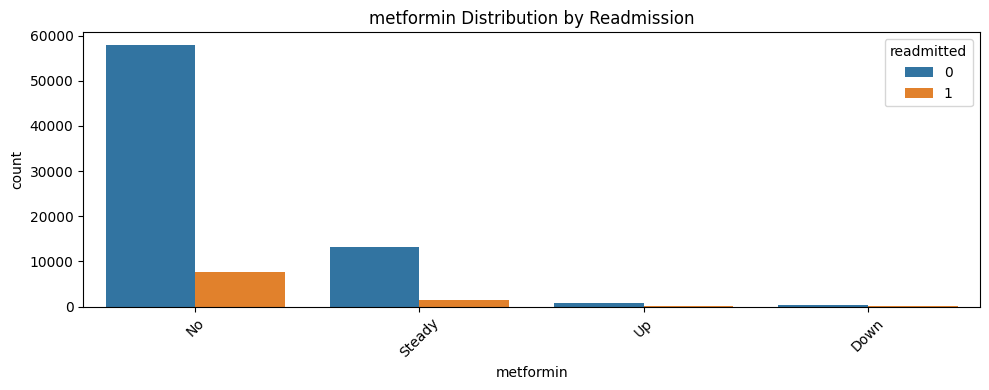

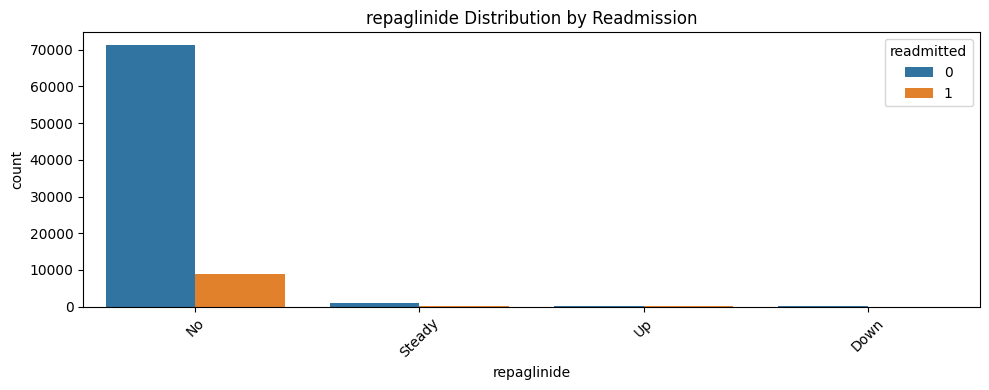

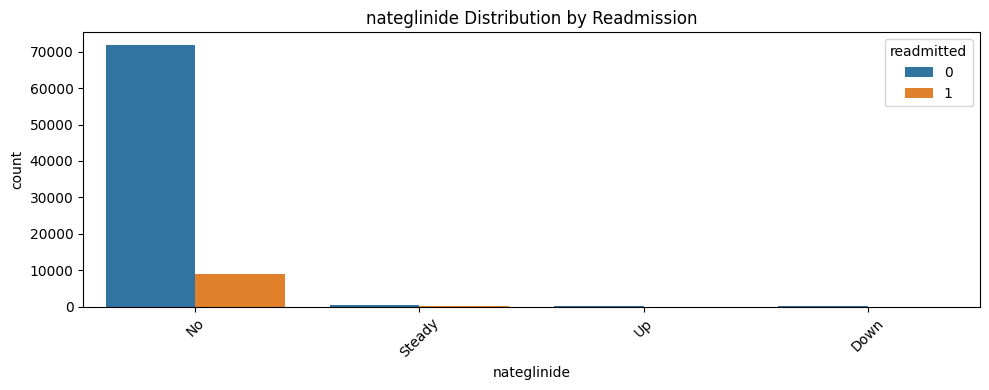

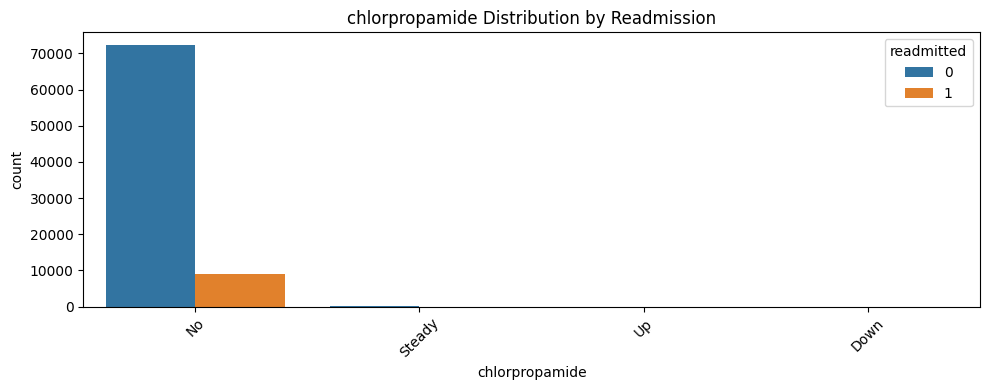

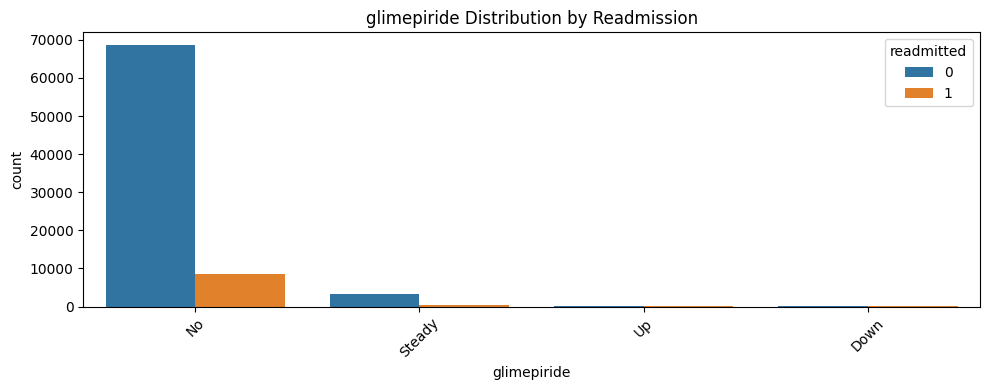

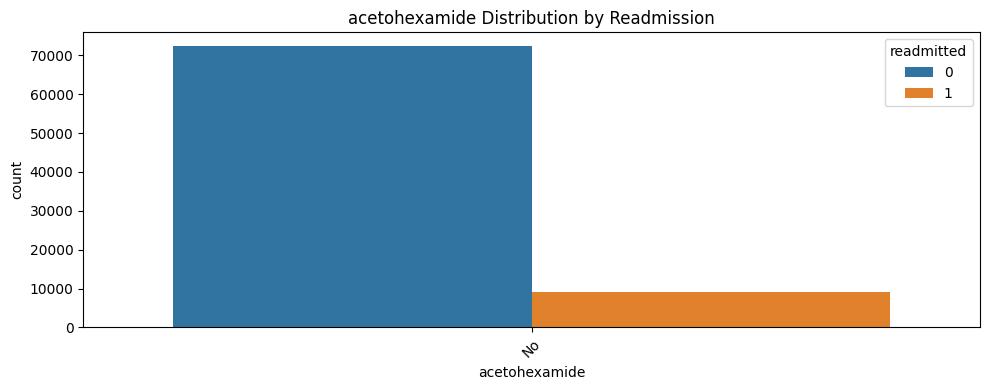

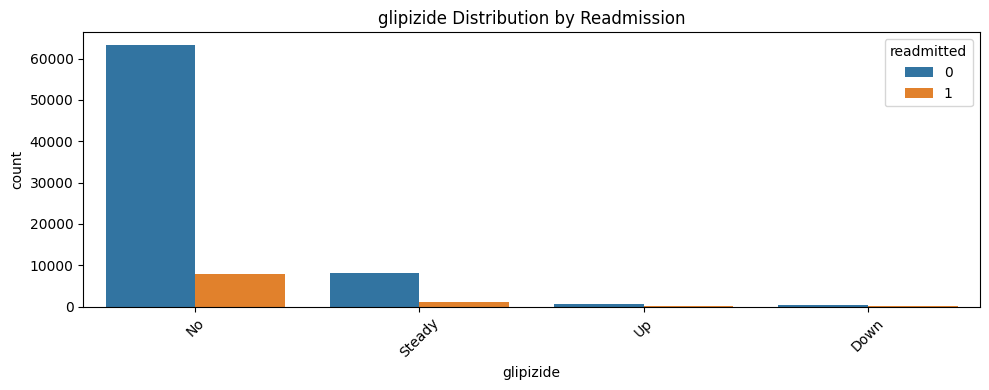

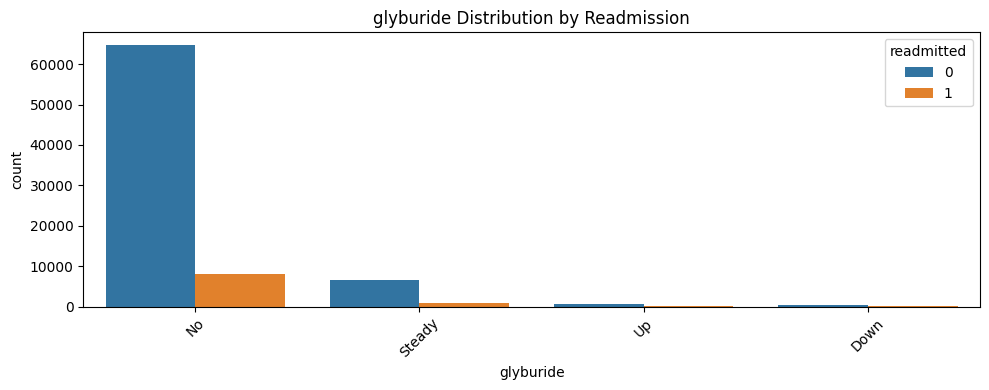

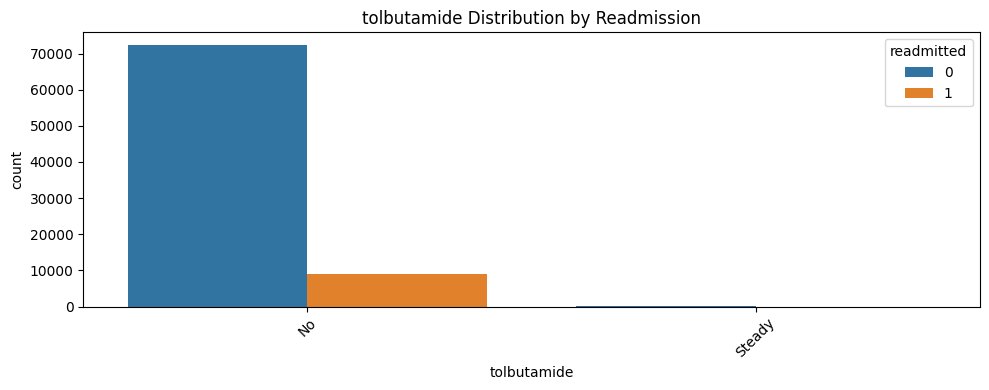

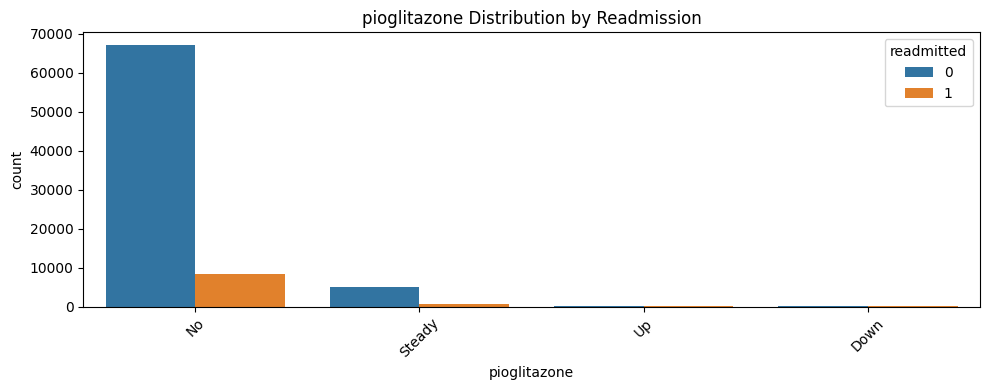

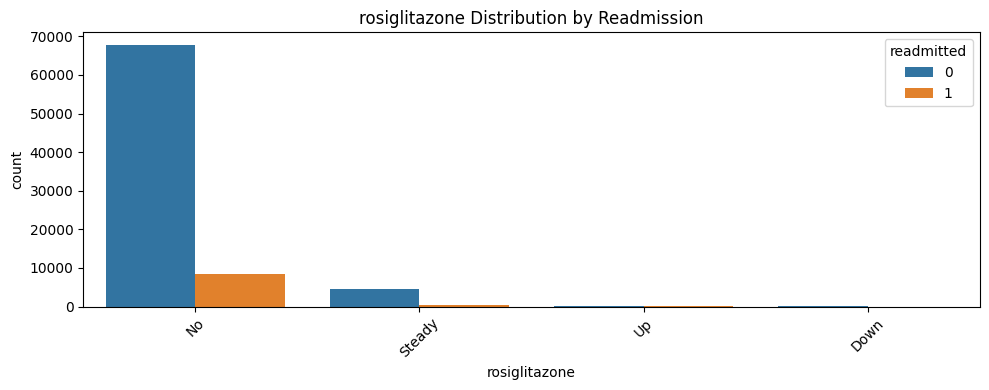

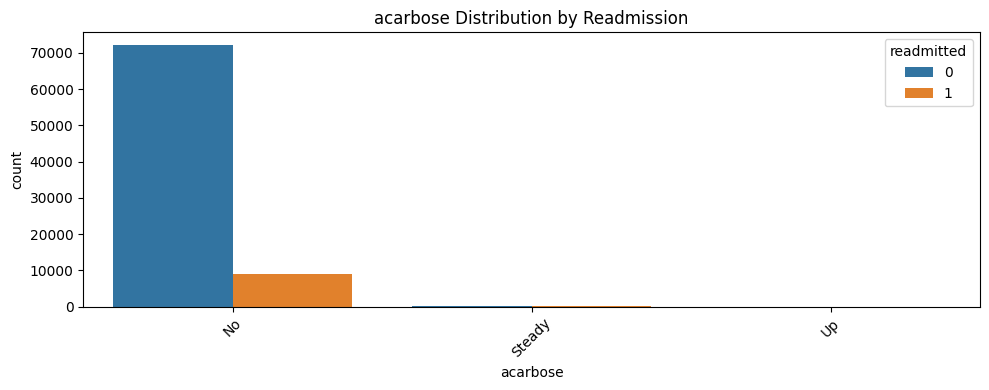

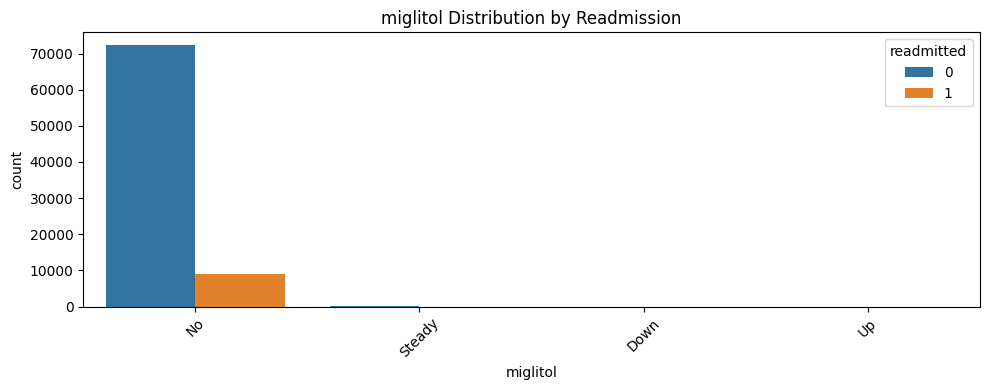

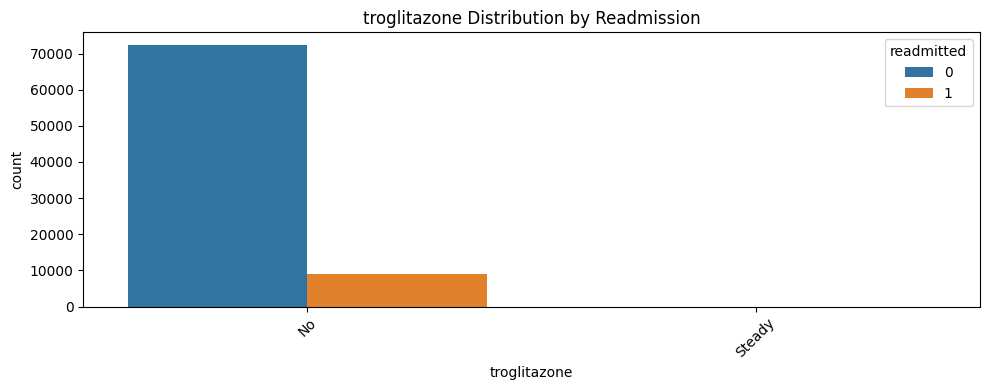

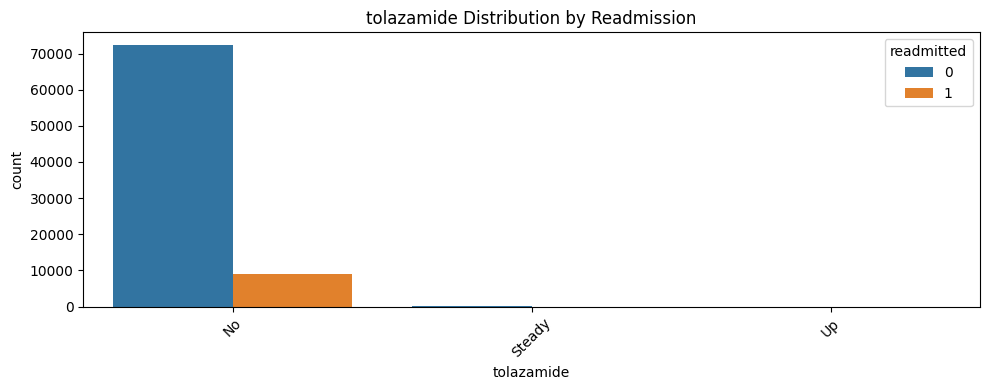

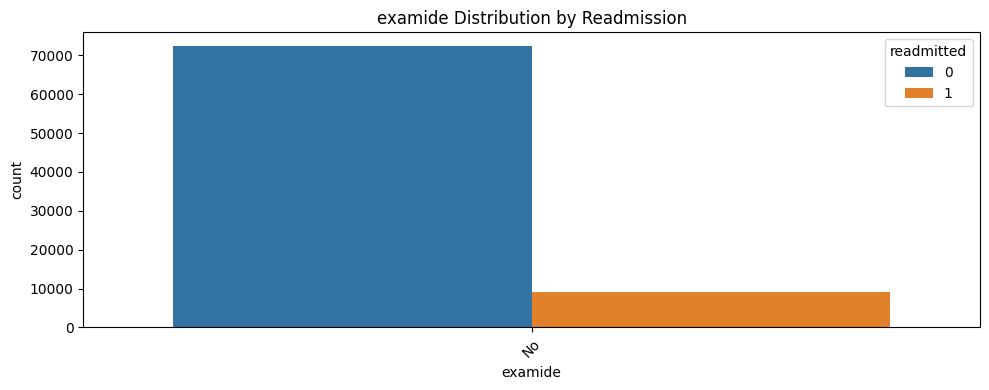

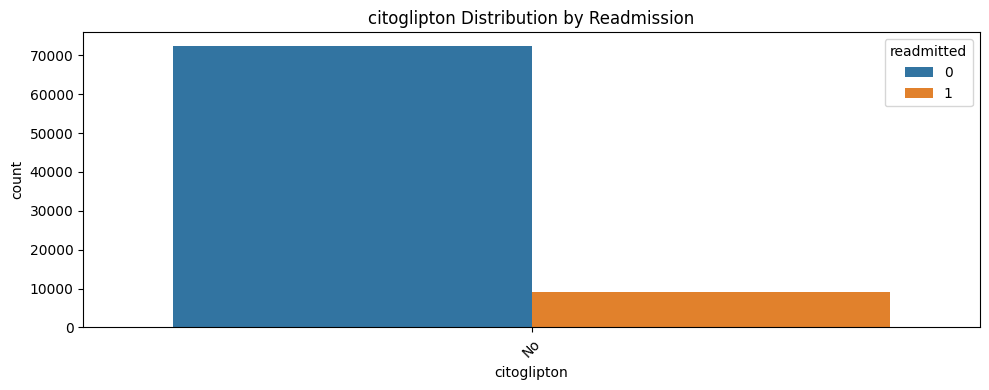

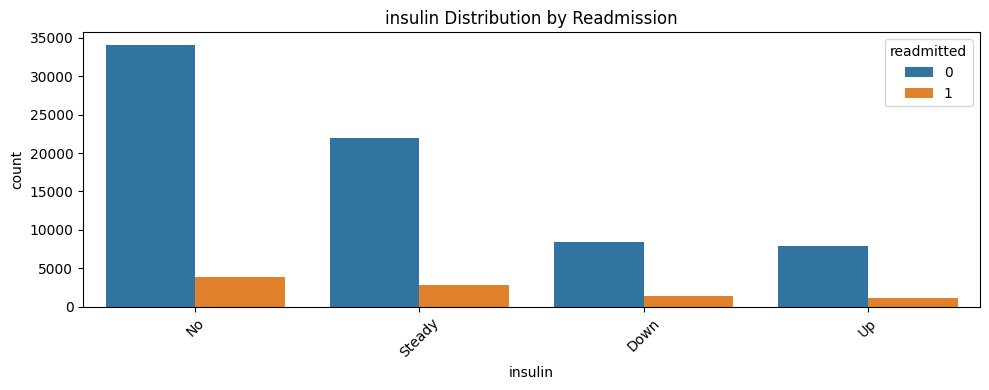

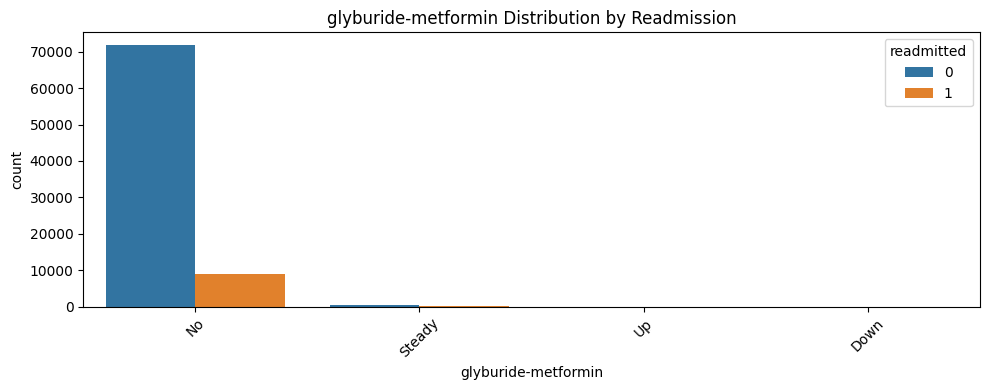

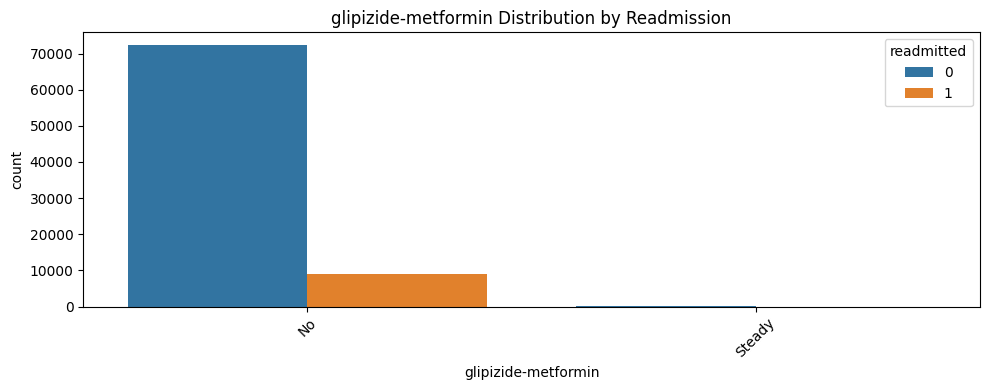

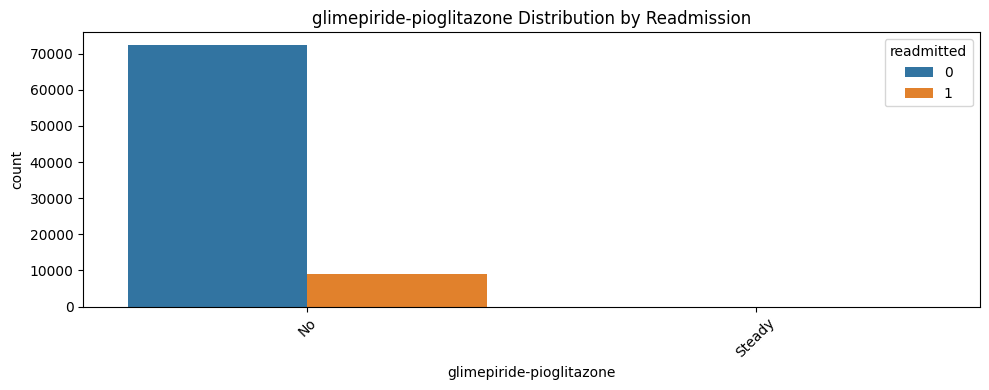

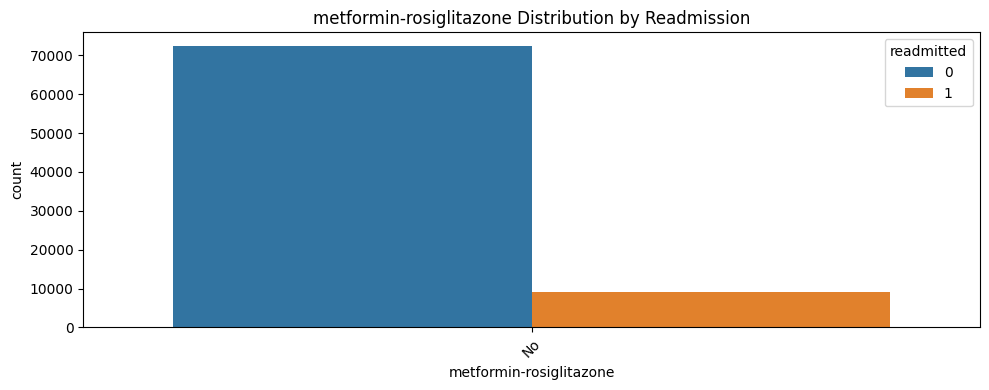

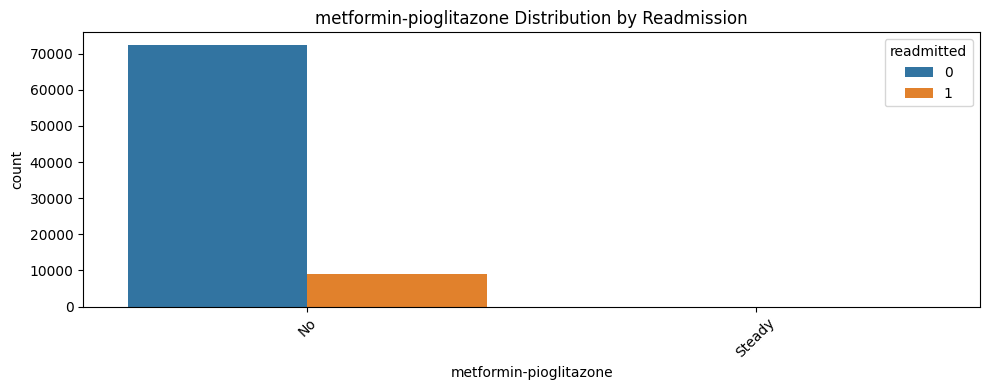

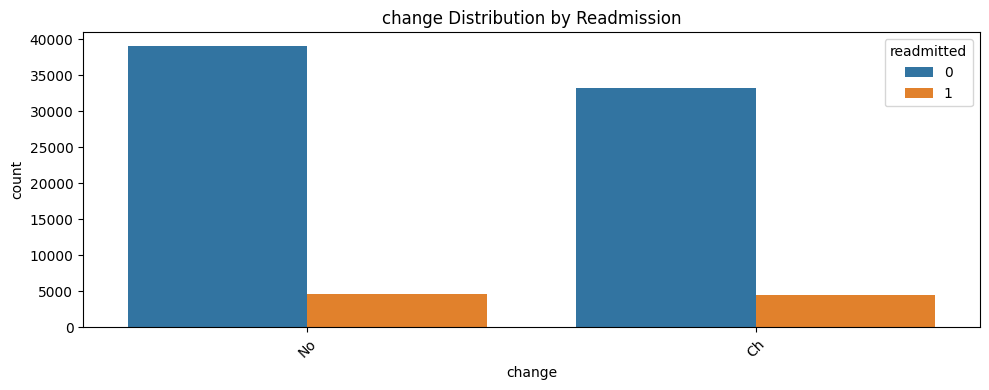

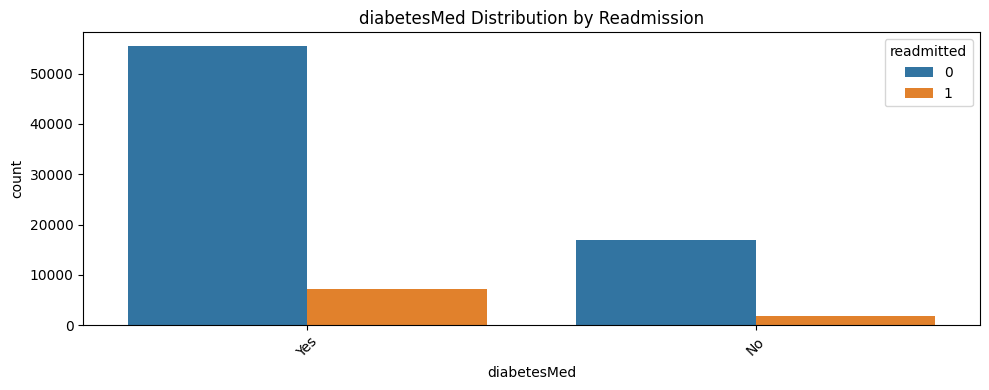

In [237]:
categorical_cols = train_df.select_dtypes(include='object').columns.tolist()

for col in categorical_cols:
    if train_df[col].nunique() < 20:
        plt.figure(figsize=(10, 4))
        sns.countplot(data=train_df, x=col, hue='readmitted', order=train_df[col].value_counts().index)
        plt.title(f'{col} Distribution by Readmission')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

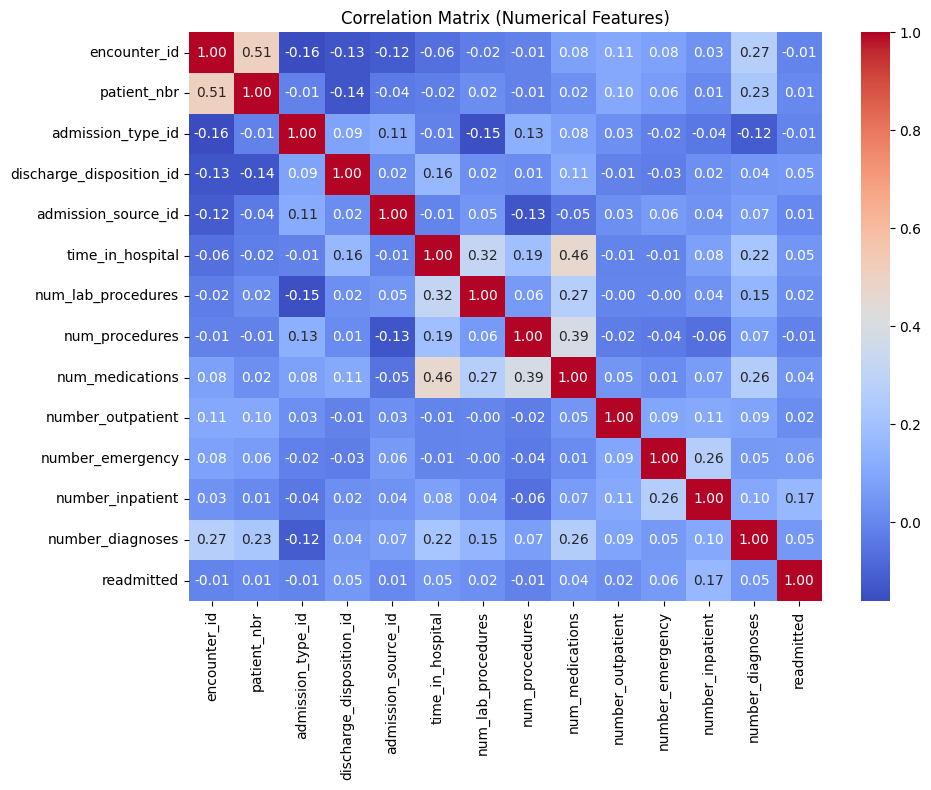

In [238]:
plt.figure(figsize=(10, 8))
corr = train_df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix (Numerical Features)')
plt.tight_layout()
plt.show()

## Feature Engineering

source: https://github.com/lelandburrill/diabetes_readmission/blob/main/p00_data_processing.ipynb

In [239]:
admission_type_id = { 1 : 'Emergency'
, 2 : 'Urgent'
, 3 : 'Elective'
, 4 : 'Newborn'
, 5 : 'Not Available'
, 6 : 'NULL'
, 7 : 'Trauma Center'
, 8 : 'Not Mapped' }

In [240]:
discharge_disposition_id = { 1 : 'Discharged to home'
, 2 : 'Discharged/transferred to another short term hospital'
, 3 : 'Discharged/transferred to SNF'
, 4 : 'Discharged/transferred to ICF'
, 5 : 'Discharged/transferred to another type of inpatient care institution'
, 6 : 'Discharged/transferred to home with home health service'
, 7 : 'Left AMA'
, 8 : 'Discharged/transferred to home under care of Home IV provider'
, 9 : 'Admitted as an inpatient to this hospital'
, 10 : 'Neonate discharged to another hospital for neonatal aftercare'
, 11 : 'Expired'
, 12 : 'Still patient or expected to return for outpatient services'
, 13 : 'Hospice / home'
, 14 : 'Hospice / medical facility'
, 15 : 'Discharged/transferred within this institution to Medicare approved swing bed'
, 16 : 'Discharged/transferred/referred another institution for outpatient services'
, 17 : 'Discharged/transferred/referred to this institution for outpatient services'
, 18 : 'NULL'
, 19 : 'Expired at home. Medicaid only, hospice'
, 20 : 'Expired in a medical facility. Medicaid only, hospice'
, 21 : 'Expired, place unknown. Medicaid only, hospice'
, 22 : 'Discharged/transferred to another rehab fac including rehab units of a hospital'
, 23 : 'Discharged/transferred to a long term care hospital'
, 24 : 'Discharged/transferred to a nursing facility certified under Medicaid but not certified under Medicare'
, 25 : 'Not Mapped'
, 26 : 'Unknown/Invalid'
, 30 : 'Discharged/transferred to another Type of Health Care Institution not Defined Elsewhere'
, 27 : 'Discharged/transferred to a federal health care facility'
, 28 : 'Discharged/transferred/referred to a psychiatric hospital of psychiatric distinct part unit of a hospital'
, 29 : 'Discharged/transferred to a Critical Access Hospital (CAH)' }

In [241]:
admission_source_id = { 1 : 'Physician Referral'
, 2 : 'Clinic Referral'
, 3 : 'HMO Referral'
, 4 : 'Transfer from a hospital'
, 5 : 'Transfer from a Skilled Nursing Facility (SNF)'
, 6 : 'Transfer from another health care facility'
, 7 : 'Emergency Room'
, 8 : 'Court/Law Enforcement'
, 9 :  'Not Available'
, 10 : 'Transfer from critial access hospital'
, 11 : 'Normal Delivery'
, 12 : 'Premature Delivery'
, 13 : 'Sick Baby'
, 14 : 'Extramural Birth'
, 15 : 'Not Available'
, 17 : 'NULL'
, 18 : 'Transfer From Another Home Health Agency'
, 19 : 'Readmission to Same Home Health Agency'
, 20 : 'Not Mapped'
, 21 : 'Unknown/Invalid'
, 22 : 'Transfer from hospital inpt/same fac reslt in a sep claim'
, 23 : 'Born inside this hospital'
, 24 : 'Born outside this hospital'
, 25 : 'Transfer from Ambulatory Surgery Center'
, 26 : 'Transfer from Hospice'}

In [242]:
data['expiration_ind'] = data['discharge_disposition_id'].isin([11,13,14,19,20,21]).astype('int')

In [243]:
data['admission_type'] = data['admission_type_id'].map(admission_type_id)
data['discharge_disposition'] = data['discharge_disposition_id'].map(discharge_disposition_id)
data['admission_source'] = data['admission_source_id'].map(admission_source_id)

data['MP_DM_payer_ind'] = ((data['payer_code'] == 'MP') | 
                            (data['payer_code'] == 'DM')).astype(int)

data.drop(columns=['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'payer_code'], inplace=True)

In [244]:
data['diag_1'] = data['diag_1'].astype(str).str[ :3]
data['diag_2'] = data['diag_2'].astype(str).str[ :3]
data['diag_3'] = data['diag_3'].astype(str).str[ :3]

data['diag_1'] = data['diag_1'].replace('?', 'ZZZ')
data['diag_2'] = data['diag_2'].replace('?', 'ZZZ')
data['diag_3'] = data['diag_3'].replace('?', 'ZZZ')

In [245]:
data['diag_1_freq'] = data.groupby('diag_1')['diag_1'].transform('count')
data['diag_2_freq'] = data.groupby('diag_2')['diag_2'].transform('count')
data['diag_3_freq'] = data.groupby('diag_3')['diag_3'].transform('count')

In [246]:
data['diag_1_428_ind'] = ( data['diag_1']=='428' ).astype(int) #CHF NOS
data['diag_1_491_ind'] = ( data['diag_1']=='491' ).astype(int) #SIMPLE CHR BRONCHITIS
data['diag_1_493_ind'] = ( data['diag_1']=='493' ).astype(int) #EXTRINSIC ASTHMA NOS

data['diag_2_403_ind'] = ( data['diag_2']=='403' ).astype(int) #MAL HY KID W CR KID I-IV
data['diag_2_707_ind'] = ( data['diag_2']=='707' ).astype(int) #DECUBITUS ULCER
data['diag_2_585_ind'] = ( data['diag_2']=='585' ).astype(int) #CHRONIC RENAL FAILURE
data['diag_2_491_ind'] = ( data['diag_2']=='491' ).astype(int) #SIMPLE CHR BRONCHITIS

data['diag_3_403_ind'] = ( data['diag_3']=='403' ).astype(int) #MAL HY KID W CR KID I-IV
data['diag_3_585_ind'] = ( data['diag_3']=='585' ).astype(int) #CHRONIC RENAL FAILURE
data['diag_3_707_ind'] = ( data['diag_3']=='707' ).astype(int) #DECUBITUS ULCER

In [247]:
data['diag_1_driver_ind'] = data['diag_1'].isin([ '403' #MAL HY KID W CR KID I-IV
, '787' #NAUSEA WITH VOMITING
, '404' #MAL HY HT/KD I-IV W/O HF
, '707' #DECUBITUS ULCER
, '572' #ABSCESS OF LIVER
, '730' #AC OSTEOMYELITIS-UNSPEC
, 'V58' #RADIOTHERAPY ENCOUNTER
, '537' #ACQ PYLORIC STENOSIS
, '443' #RAYNAUD'S SYNDROME
, '292' #DRUG WITHDRAWAL
, '496' #CHR AIRWAY OBSTRUCT NEC
, '585' #CHRONIC RENAL FAILURE
, '282' #HEREDITARY SPHEROCYTOSIS
, '799' #ASPHYXIA
, '284' #CONGEN APLASTIC ANEMIA
, '567' #PERITONITIS IN INFEC DIS
, '293' #DELIRIUM D/T OTHER COND
, '924' #CONTUSION OF THIGH
, '340' #MULTIPLE SCLEROSIS
, '514' #PULM CONGEST/HYPOSTASIS
, '485' #BRONCHOPNEUMONIA ORG NOS
, '714' #RHEUMATOID ARTHRITIS
, '277' #CYSTIC FIBROS W/O ILEUS
, '150' #MAL NEO CERVICAL ESOPHAG
, '135' #SARCOIDOSIS
, '522']).astype(int) #PULPITIS

In [248]:
data['diag_2_driver_ind'] = data['diag_2'].isin([ '571' #ALCOHOLIC FATTY LIVER
, '404' #MAL HY HT/KD I-IV W/O HF
, '536' #ACHLORHYDRIA
, '202' #NDLR LYM UNSP XTRNDL ORG
, '396' #MITRAL/AORTIC STENOSIS
, '304' #OPIOID DEPENDENCE-UNSPEC
, '444' #ABD AORTIC EMBOLISM
, '581' #NEPHROTIC SYN, PROLIFER
, '731' #OSTEITIS DEFORMANS NOS
, 'E94' #ADV EFF ANALEPTICS
, '397' #TRICUSPID VALVE DISEASE
, '595' #ACUTE CYSTITIS
, '205' #AC MYL LEUK WO ACHV RMSN
, '490' #BRONCHITIS NOS
, '459' #HEMORRHAGE NOS
, '189' #MALIG NEOPL KIDNEY
, '154' #MAL NEO RECTOSIGMOID JCT
, '332' #PARALYSIS AGITANS
, 'V49' #DEFICIENCIES OF LIMBS
, '681' #CELLULITIS, FINGER NOS
, '150' #MAL NEO CERVICAL ESOPHAG
, '537' #ACQ PYLORIC STENOSIS
, '094' ]).astype(int) #TABES DORSALIS

In [249]:
data['diag_3_driver_ind'] = data['diag_3'].isin([  '682' #CELLULITIS OF FACE
, '070' #HEPATITIS A WITH COMA
, '536' #ACHLORHYDRIA
, 'V42' #KIDNEY TRANSPLANT STATUS
, '443' #RAYNAUD'S SYNDROME
, '304' #OPIOID DEPENDENCE-UNSPEC
, '284' #CONGEN APLASTIC ANEMIA
, '466' #ACUTE BRONCHITIS
, '459' #HEMORRHAGE NOS
, '581' #NEPHROTIC SYN, PROLIFER
, '337' #IDIOPATH AUTO NEUROPATHY
, '583' #PROLIFERAT NEPHRITIS NOS
, '203' #MULT MYE W/O ACHV RMSON
, 'V46' #DEPENDENCE ON ASPIRATOR
, '482' #K. PNEUMONIAE PNEUMONIA
, 'V49' #DEFICIENCIES OF LIMBS
, '444' #ABD AORTIC EMBOLISM
, '174' #MALIG NEO NIPPLE
, '456' #ESOPHAG VARICES W BLEED
, '519' #TRACHEOSTOMY COMP NOS
, 'E92' #ACC-POWERED LAWN MOWER
, 'V62' #UNEMPLOYMENT
, '356' #HERED PERIPH NEUROPATHY
, '711' #PYOGEN ARTHRITIS-UNSPEC
, '053' ]).astype(int)  #HERPES ZOSTER MENINGITIS

In [250]:
#add patient-level some features
data['encounter_ct'] = data['patient_nbr'].map(data.groupby('patient_nbr')['encounter_id'].nunique())
data['mb_time_in_hospital'] = data.groupby('patient_nbr')['time_in_hospital'].transform('sum')
data['mb_num_lab_procedures_ct'] = data.groupby('patient_nbr')['num_lab_procedures'].transform('sum')
data['mb_num_procedures_ct'] = data.groupby('patient_nbr')['num_procedures'].transform('sum')
data['mb_num_medications_ct'] = data.groupby('patient_nbr')['num_medications'].transform('sum')
data['mb_number_outpatient_ct'] = data.groupby('patient_nbr')['number_outpatient'].transform('sum')
data['mb_number_emergency_ct'] = data.groupby('patient_nbr')['number_emergency'].transform('sum')
data['mb_number_inpatient_ct'] = data.groupby('patient_nbr')['number_inpatient'].transform('sum')
data['mb_number_diagnoses_ct'] = data.groupby('patient_nbr')['number_diagnoses'].transform('sum')

In [251]:
data.drop(columns=['weight', 'medical_specialty', 'expiration_ind'], inplace=True)

In [252]:
data.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age',
       'time_in_hospital', 'num_lab_procedures', 'num_procedures',
       'num_medications', 'number_outpatient', 'number_emergency',
       'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses',
       'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide',
       'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide',
       'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
       'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton',
       'insulin', 'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted',
       'admission_type', 'discharge_disposition', 'admission_source',
       'MP_DM_payer_ind', 'diag_1_freq', 'diag_2_freq', 'diag_3_freq',
       'diag_1_428_ind', 'diag_1_491_ind', 'diag_1_493_ind', 'diag_2_403_ind',
   

# Modeling

In [253]:
data

,encounter_id,patient_nbr,race,gender,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,admission_type,discharge_disposition,admission_source,MP_DM_payer_ind,diag_1_freq,diag_2_freq,diag_3_freq,diag_1_428_ind,diag_1_491_ind,diag_1_493_ind,diag_2_403_ind,diag_2_707_ind,diag_2_585_ind,diag_2_491_ind,diag_3_403_ind,diag_3_585_ind,diag_3_707_ind,diag_1_driver_ind,diag_2_driver_ind,diag_3_driver_ind,encounter_ct,mb_time_in_hospital,mb_num_lab_procedures_ct,mb_num_procedures_ct,mb_num_medications_ct,mb_number_outpatient_ct,mb_number_emergency_ct,mb_number_inpatient_ct,mb_number_diagnoses_ct
0,2278392,8222157,Caucasian,Female,[0-10),1,41,0,1,0,0,0,250,nan,nan,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,0,NULL,Not Mapped,Physician Referral,0,8757,358,1423,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,41,0,1,0,0,0,1
1,149190,55629189,Caucasian,Female,[10-20),3,59,0,18,0,0,0,276,250,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,0,Emergency,Discharged to home,Emergency Room,0,1889,12794,69,0,0,0,0,0,0,0,0,0,0,0,0,0,1,3,59,0,18,0,0,0,9
2,64410,86047875,AfricanAmerican,Female,[20-30),2,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,0,Emergency,Discharged to home,Emergency Room,0,285,12794,37,0,0,0,0,0,0,0,0,0,0,0,0,0,1,2,11,5,13,2,0,1,6
3,500364,82442376,Caucasian,Male,[30-40),2,44,1,16,0,0,0,8,250,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,0,Emergency,Discharged to home,Emergency Room,0,515,12794,2357,0,0,0,0,0,0,0,1,0,0,0,0,0,1,2,44,1,16,0,0,0,7
4,16680,42519267,Caucasian,Male,[40-50),1,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,0,Emergency,Discharged to home,Emergency Room,0,320,85,17157,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,51,0,8,0,0,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),3,51,0,16,0,0,0,250,291,458,9,NaN,>8,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Down,No,No,No,No,No,Ch,Yes,0,Emergency,Discharged/transferred to SNF,Emergency Room,0,8757,74,285,0,0,0,0,0,0,0,0,0,0,0,0,0,2,8,80,3,38,0,0,0,16
101762,443847782,74694222,AfricanAmerican,Female,[80-90),5,33,3,18,0,0,1,560,276,787,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Yes,0,Emergency,Discharged/transferred to ICF,Transfer from a Skilled Nursing Facility (SNF),0,876,6752,358,0,0,0,0,0,0,0,0,0,0,0,0,0,2,11,79,4,48,0,0,1,18
101763,443854148,41088789,Caucasian,Male,[70-80),1,53,0,9,1,0,0,38,590,296,13,NaN,NaN,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Down,No,No,No,No,No,Ch,Yes,0,Emergency,Discharged to home,Emergency Room,0,1688,134,214,0,0,0,0,0,0,0,0,0,0,0,0,0,3,5,125,2,20,1,0,1,25
101764,443857166,31693671,Caucasian,Female,[80-90),10,45,2,21,0,0,1,996,285,998,9,NaN,NaN,No,No,No,No,No,No,Steady,No,No,Steady,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,0,Urgent,Discharged/transferred to SNF,Emergency Room,0,1967,1520,316,0,0,0,0,0,0,0,0,0,0,0,0,0,4,29,216,8,65,0,0,3,28


In [228]:
train_df = data[data['patient_nbr'].isin(train_patients)].reset_index(drop=True)
test_df = data[data['patient_nbr'].isin(test_patients)].reset_index(drop=True)

print("Train readmitted rate:", train_df['readmitted'].mean())
print("Test readmitted rate:", test_df['readmitted'].mean())

Train readmitted rate: 0.11152224421306256
Test readmitted rate: 0.11190557813800872
